In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/garbage_classification/data

 Cardboard	  Glass  'Miscellaneous Trash'	 Plastic	  Vegetation
'Food Organics'   Metal   Paper			'Textile Trash'


In [ ]:
!unzip /content/drive/MyDrive/garbage_classification/data/archive.zip -d /content/drive/MyDrive/garbage_classification/data/images


unzip:  cannot find or open /content/drive/MyDrive/garbage_classification/data/archive.zip, /content/drive/MyDrive/garbage_classification/data/archive.zip.zip or /content/drive/MyDrive/garbage_classification/data/archive.zip.ZIP.


In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 50.2 MB/s eta 0:00:00


In [ ]:
!cp -r /content/drive/MyDrive/garbage_classification/data /content/local_data

Found 4767 files belonging to 9 classes.
Using 3814 files for training.
Found 4767 files belonging to 9 classes.
Using 953 files for validation.
Loading saved model...

Overall Metrics
Accuracy: 0.8079748163693599
Precision (macro): 0.8162652132111865
Recall (macro): 0.8020345694559915
F1-score (macro): 0.8069533319254172

Classification Report
                     precision    recall  f1-score   support

          Cardboard       0.78      0.82      0.79        76
      Food Organics       0.89      0.90      0.90        83
              Glass       0.90      0.69      0.78        81
              Metal       0.85      0.84      0.84       169
Miscellaneous Trash       0.66      0.60      0.63        93
              Paper       0.88      0.86      0.87       119
            Plastic       0.73      0.82      0.77       182
      Textile Trash       0.74      0.78      0.76        69
         Vegetation       0.92      0.90      0.91        81

           accuracy                      

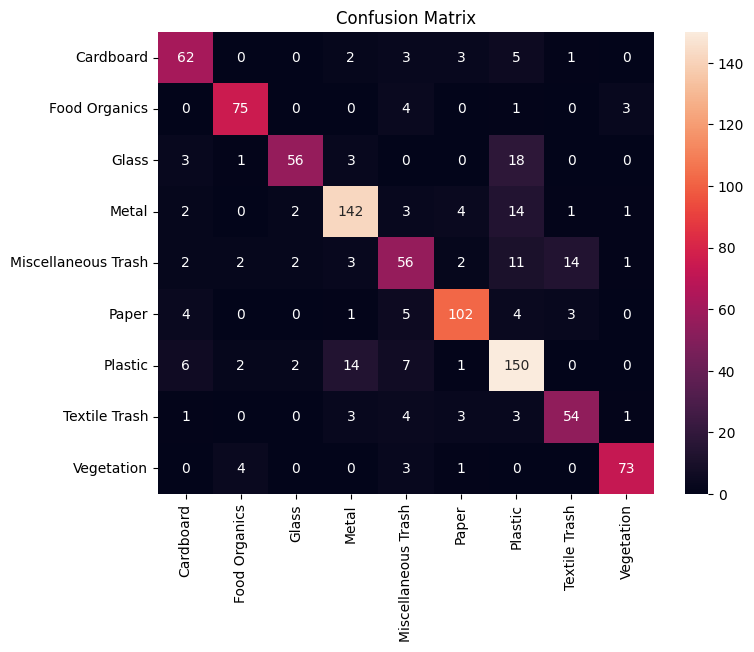

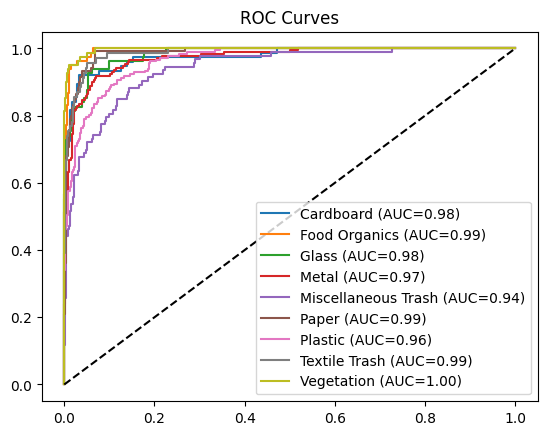

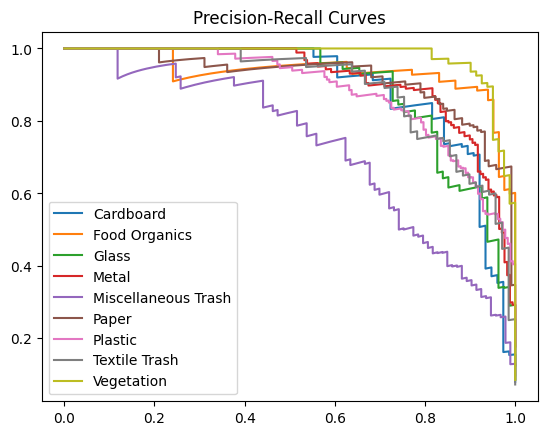

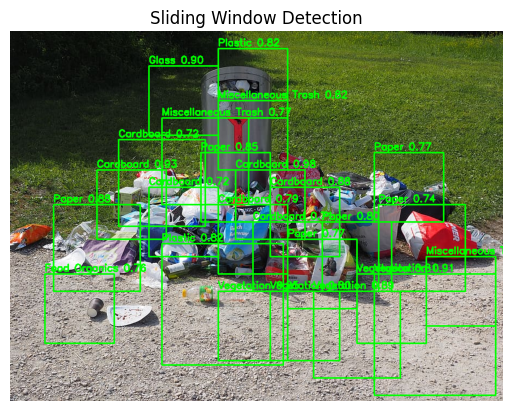

In [ ]:
"""
FULL PIPELINE:
Garbage Classification + High-Recall Sliding Window Detection
Optimized for T4 GPU + Full Evaluation + Persistent Saving
"""

import os
import time
import shutil
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import mixed_precision

# =====================================================
# ENABLE MIXED PRECISION (T4 Tensor Core Acceleration)
# =====================================================

mixed_precision.set_global_policy('mixed_float16')

# =====================================================
# CONFIG
# =====================================================

class Config:
    drive_data_root = "/content/drive/MyDrive/garbage_classification/data"
    local_data_root = "/content/local_data"
    model_dir = Path("/content/drive/MyDrive/garbage_classification/model_cache")
    model_name = "garbage_classifier_full.keras"
    large_test_image = "/content/drive/MyDrive/garbage_classification/test_images/test2.jpg"
    batch_size = 64
    epochs = 20
    lr = 1e-4
    img_size = (224,224)

cfg = Config()
cfg.model_dir.mkdir(parents=True, exist_ok=True)
model_path = cfg.model_dir / cfg.model_name

# =====================================================
# COPY DATA LOCALLY (FASTER I/O)
# =====================================================

if not os.path.exists(cfg.local_data_root):
    print("Copying dataset locally...")
    shutil.copytree(cfg.drive_data_root, cfg.local_data_root)

data_root = cfg.local_data_root

# =====================================================
# FAST DATA PIPELINE
# =====================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_root,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=cfg.img_size,
    batch_size=cfg.batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_root,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=cfg.img_size,
    batch_size=cfg.batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x,y: (preprocess_input(x), y),
                        num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

val_ds = val_ds.map(lambda x,y: (preprocess_input(x), y),
                    num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# =====================================================
# LOAD OR TRAIN MODEL
# =====================================================

if model_path.exists():
    print("Loading saved model...")
    model = load_model(model_path)

else:
    print("Training new model...")

    base_model = ResNet50(weights="imagenet",
                          include_top=False,
                          input_shape=(224,224,3))
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes,
                    activation="softmax",
                    dtype="float32")(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    model.compile(
        optimizer=Adam(cfg.lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.epochs
    )

    model.save(model_path)
    print("Model saved.")

    # =========================
    # Plot Loss & Accuracy
    # =========================

    plt.figure()
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Val Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.show()

    plt.figure()
    plt.plot(history.history['accuracy'], label="Train Acc")
    plt.plot(history.history['val_accuracy'], label="Val Acc")
    plt.legend()
    plt.title("Accuracy Curve")
    plt.show()

# =====================================================
# EVALUATION
# =====================================================

y_true, y_pred, y_scores = [], [], []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_scores.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

accuracy = np.mean(y_true == y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

print("\nOverall Metrics")
print("Accuracy:", accuracy)
print("Precision (macro):", precision_macro)
print("Recall (macro):", recall_macro)
print("F1-score (macro):", f1_macro)

print("\nClassification Report")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

# ROC Curves
y_true_bin = label_binarize(y_true, classes=range(num_classes))
plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curves")
plt.show()

# Precision-Recall Curves
plt.figure()
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i], y_scores[:, i])
    plt.plot(recall, precision, label=class_names[i])
plt.legend()
plt.title("Precision-Recall Curves")
plt.show()

# =====================================================
# HIGH-RECALL MULTI-SCALE SLIDING WINDOW
# =====================================================

def sliding_window_detection(image_path):

    img = cv2.imread(image_path)
    H, W = img.shape[:2]

    window_sizes = [224, 160, 128]
    stride_ratio = 0.25
    conf_thresh = 0.7
    nms_iou = 0.3

    boxes, scores, labels = [], [], []

    for window_size in window_sizes:

        stride = int(window_size * stride_ratio)

        for y in range(0, H - window_size + 1, stride):
            for x in range(0, W - window_size + 1, stride):

                crop = img[y:y+window_size, x:x+window_size]
                crop_resized = cv2.resize(crop, (224,224))
                crop_array = preprocess_input(
                    np.expand_dims(crop_resized, axis=0))

                probs = model.predict(crop_array, verbose=0)
                conf = np.max(probs)
                cls = np.argmax(probs)

                if conf > conf_thresh:
                    boxes.append([x,y,x+window_size,y+window_size])
                    scores.append(conf)
                    labels.append(cls)

    if len(boxes) == 0:
        print("No detections.")
        return img

    boxes = tf.convert_to_tensor(boxes, dtype=tf.float32)
    scores = tf.convert_to_tensor(scores)

    selected = tf.image.non_max_suppression(
        boxes, scores,
        max_output_size=1000,
        iou_threshold=nms_iou
    )

    for i in selected.numpy():
        x1,y1,x2,y2 = boxes[i]
        cls = class_names[labels[i]]
        score = scores[i].numpy()

        cv2.rectangle(img,(int(x1),int(y1)),
                      (int(x2),int(y2)),(0,255,0),2)
        cv2.putText(img,f"{cls} {score:.2f}",
                    (int(x1),int(y1)-5),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2)

    return img

# =====================================================
# RUN DETECTION
# =====================================================
large_test_image = "/content/drive/MyDrive/garbage_classification/test_images/test3.jpg"
if os.path.exists(large_test_image):
    result = sliding_window_detection(large_test_image)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Sliding Window Detection")
    plt.show()

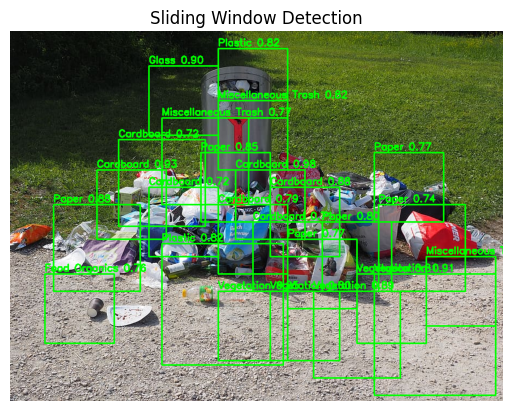

In [ ]:
large_test_image = "/content/drive/MyDrive/garbage_classification/test_images/test3.jpg"
if os.path.exists(large_test_image):
    result = sliding_window_detection(large_test_image)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Sliding Window Detection")
    plt.show()